In [13]:
import os
import pandas as pd
from os.path import join as pjoin
from itertools import product

config_file = '../dataset_configs/adult_dataset_t7.json'
from catrace.dataset import load_dataset_config
dsconfig = load_dataset_config(config_file)
capacity_dir = os.path.join(dsconfig.results_dir, 'capacity')
seed = 8887
N=400 # number of neurons
M=70 # number of data points

In [14]:
from matplotlib import rcParams
rcParams['font.family'] = 'Arial'
rcParams['pdf.fonttype'] = 42  # Use TrueType fonts
rcParams['axes.linewidth'] = 0.5
rcParams['xtick.major.width'] = 0.5
rcParams['ytick.major.width'] = 0.5

In [15]:
time_windows = [[25, 48], [32, 56], [40, 63], [47, 71], [55, 78], [62, 86], [70, 93], [77, 101], [85, 108], [92, 116], [100, 123], [107, 131], [115, 138], [137, 161], [130, 153], [122, 146]]

dfs = []
for window in time_windows:
    window_key = f'window_{window[0]}_{window[1]}'
    jobname = f'capacity_sweep_{window_key}_N{N}_M{M}_master_seed{seed}'
    input_dir = pjoin(capacity_dir, jobname)
    df_result_file = pjoin(input_dir, f'df_result.pkl')
    dfs.append(pd.read_pickle(df_result_file))


In [16]:
capdf = pd.concat(dfs)
capdf = capdf[capdf.index.get_level_values('shuffle') == False]
capdf.reset_index(level=['condition', 'window_0', 'window_1'], inplace=True)
capdf['start_time'] = (capdf['window_0'] / 7.5 - 3.3).round()
capdf['end_time'] = (capdf['window_1'] / 7.5 - 3.3).round()
capdf['middle_time'] = ((capdf['start_time'] + capdf['end_time']) / 2)

In [17]:
capdf['middle_time'].unique()

array([ 1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5, 11.5,
       12.5, 13.5, 16.5, 15.5, 14.5])

In [18]:
capdf

condition  \
fish_id                            odor1 odor2 shuffle seed              
Extracted_Data_mock1_Fish1         His   Trp   False   8888      naive   
                                   Ala   His   False   8887      naive   
                                         Trp   False   8891      naive   
                                   Ser   Trp   False   8890      naive   
                                   His   Ser   False   8892      naive   
...                                                                ...   
Extracted_Data_ExpA10_Setup3_Fish1 Ala   Trp   False   18980   trained   
                                   His   Trp   False   18983   trained   
                                         Ser   False   18982   trained   
                                   Ala   Ser   False   18979   trained   
                                   Ser   Trp   False   18984   trained   

                                                              window_0  \
fish_id                            odor1 odor2 shuffle seed              
Extracted_Data_mock1_Fish1         His   Trp   False   8888         25   
                                   Ala   His   False   8887         25   
                                         Trp   False   8891         25   
                                   Ser   Trp   False   8890         25   
                                   His   Ser   False   8892         25   
...                                                                ...   
Extracted_Data_ExpA10_Setup3_Fish1 Ala   Trp   False   18980       122   
                                   His   Trp   False   18983       122   
                                         Ser   False   18982       122   
                                   Ala   Ser   False   18979       122   
                                   Ser   Trp   False   18984       122   

                                                              window_1  \
fish_id                            odor1 odor2 shuffle seed              
Extracted_Data_mock1_Fish1         His   Trp   False   8888         48   
                                   Ala   His   False   8887         48   
                                         Trp   False   8891         48   
                                   Ser   Trp   False   8890         48   
                                   His   Ser   False   8892         48   
...                                                                ...   
Extracted_Data_ExpA10_Setup3_Fish1 Ala   Trp   False   18980       146   
                                   His   Trp   False   18983       146   
                                         Ser   False   18982       146   
                                   Ala   Ser   False   18979       146   
                                   Ser   Trp   False   18984       146   

                                                              capacity  \
fish_id                            odor1 odor2 shuffle seed              
Extracted_Data_mock1_Fish1         His   Trp   False   8888   0.064754   
                                   Ala   His   False   8887   0.093279   
                                         Trp   False   8891   0.075982   
                                   Ser   Trp   False   8890   0.071848   
                                   His   Ser   False   8892   0.061800   
...                                                                ...   
Extracted_Data_ExpA10_Setup3_Fish1 Ala   Trp   False   18980  0.117372   
                                   His   Trp   False   18983  0.115774   
                                         Ser   False   18982  0.122783   
                                   Ala   Ser   False   18979  0.085452   
                                   Ser   Trp   False   18984  0.128292   

                                                              dimension  \
fish_id                            odor1 odor2 shuffle seed               
Extracted_Data_mock1_Fish1         His   Trp   False   8888

Text(0, 0.5, 'Capacity')

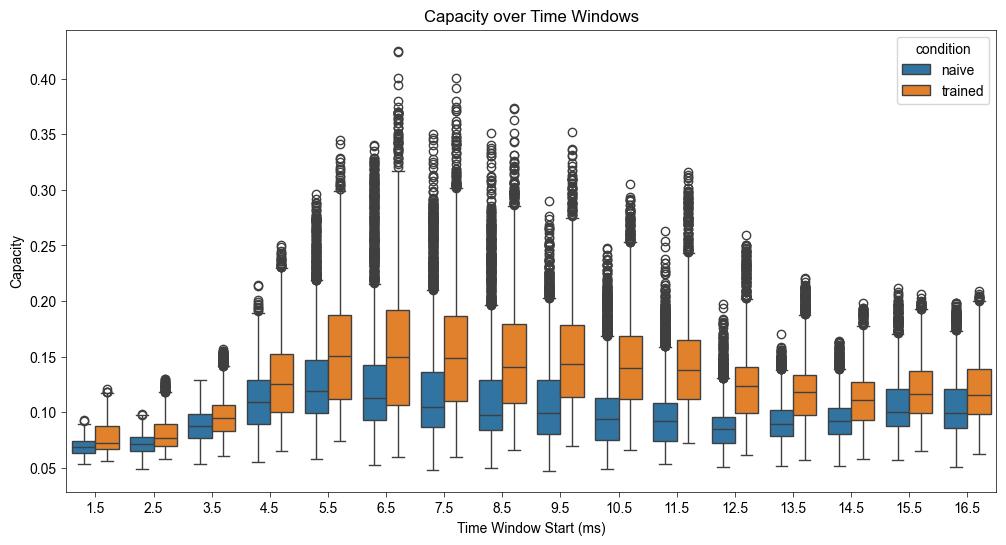

In [19]:

# Plot boxplot with window_0 as x, capacity as y, and condition as hue
import seaborn as sns
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=capdf, x='middle_time', y='capacity', hue='condition', ax=ax)
ax.set_title('Capacity over Time Windows')
ax.set_xlabel('Time Window Start (ms)')
ax.set_ylabel('Capacity')

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_measure_over_time_windows(capdf, measure='capacity', window_col='middle_time', hue_col='condition', errorbar='se', figsize=(5, 3.5), sns_params=None):
    """
    Plot a measure (e.g., capacity) over time windows with conditions as hue.
    
    Parameters:
    - capdf: DataFrame containing the data.
    - measure: The measure to plot (default is 'capacity').
    - window_col: Column name for the time window (default is 'window_0').
    - hue_col: Column name for the condition (default is 'condition').
    - figsize: Tuple specifying the figure size (default is (5, 3.5)).
    """
    fig, ax = plt.subplots(figsize=figsize)
    color_dict = {'naive': 'tab:blue', 
                'arg-phe': 'salmon',
                'phe-arg': 'm',
                'phe-trp': 'tab:green',
                'trained': 'tab:orange',
    }
    if sns_params is None:
        sns_params = {}
    sns.lineplot(
        data=capdf.sort_values(window_col),
        x=window_col, y=measure, hue=hue_col,
        estimator='mean',      # aggregate by mean at each (window_0, condition)
        errorbar=errorbar,         # shaded band = standard deviation
        marker='o',            # optional: markers at means
        ax=ax,
        palette=color_dict,   # use custom color palette
        **sns_params           # pass additional sns parameters (e.g., markersize)
    )
    ax.set_title(f'{measure.capitalize()} over Time Windows')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel(measure.capitalize())
    ax.legend(title=hue_col)
    plt.tight_layout()
    return fig, ax


In [21]:
paper_fig_dir = '../../figures_for_paper/adult/capacity/timecourse'
os.makedirs(paper_fig_dir, exist_ok=True)

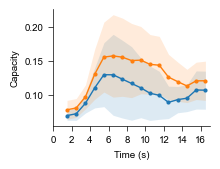

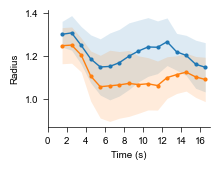

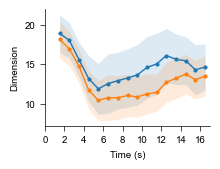

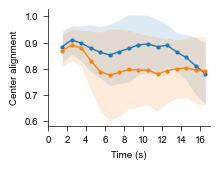

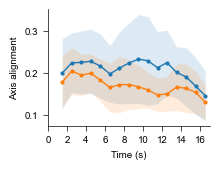

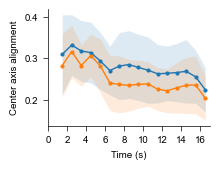

In [22]:
measures = ['capacity', 'radius', 'dimension', 'center_alignment', 'axis_alignment', 'center_axis_alignment']
ytick_intervals = [0.05, None, None, None, None, None]
for measure in measures:
    figsize=(2.3,2.0)
    # Decrease marker size in sns.lineplot by passing sns_params
    # linewidth = 1
    # Also remove the white edge around markers by setting markeredgewidth to 0
    sns_params = {'markersize': 3,
                  'linewidth': 1,
                  'markeredgewidth': 0,
                   # Set the std shading with alpha = 0.3, only for the shading of the standard deviation area, not the markers, not the lines
                   'err_kws': {'alpha': 0.15,
                               "linewidth": 0}}
    fig, ax = plot_measure_over_time_windows(capdf, measure=measure, window_col='middle_time', hue_col='condition', errorbar='sd', figsize=figsize,
                                             sns_params=sns_params)
    ax.set_xlim((0,17))
    from matplotlib.ticker import MultipleLocator
    ax.xaxis.set_major_locator(MultipleLocator(1))
    sns.despine()
    # Set xlabel, ylabel, tick fontsize to 7
    ax.set_xlabel('Time (s)', fontsize=7)
    ylabel = measure.replace('_', ' ').capitalize()
    ax.set_ylabel(ylabel, fontsize=7)
    ax.tick_params(axis='both', which='major', labelsize=7)
    # Set x tick interval to 2
    from matplotlib.ticker import MultipleLocator
    ax.xaxis.set_major_locator(MultipleLocator(2))
    ytick_interval = ytick_intervals[measures.index(measure)]
    if ytick_interval is not None:
        ax.yaxis.set_major_locator(MultipleLocator(ytick_interval))
    plt.tight_layout()
    # Remove legend
    ax.legend_.remove()
    # Remove title
    ax.set_title('')
    # Save figure
    fig_name = f'{measure}_timecourse_with_std.pdf'
    fig_path = pjoin(paper_fig_dir, fig_name)
    fig.savefig(fig_path)


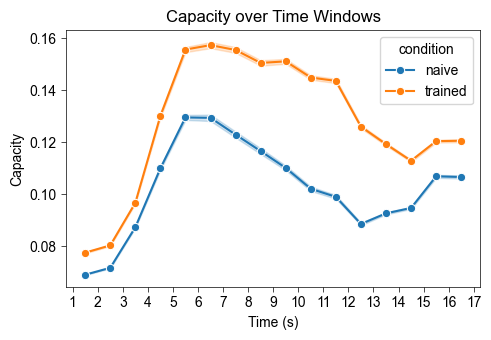

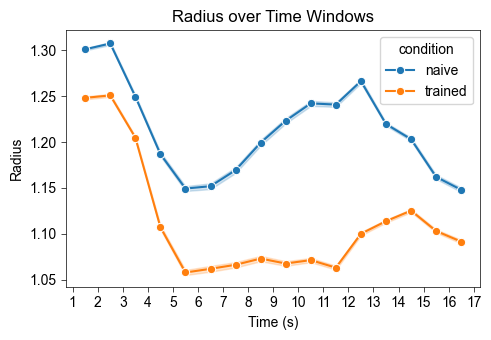

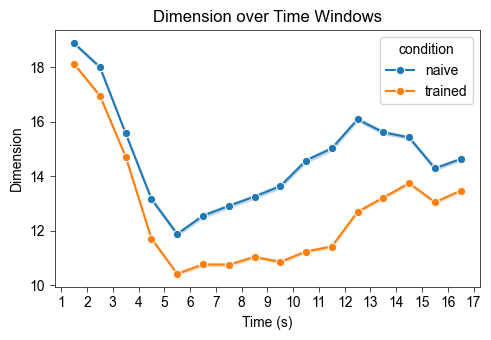

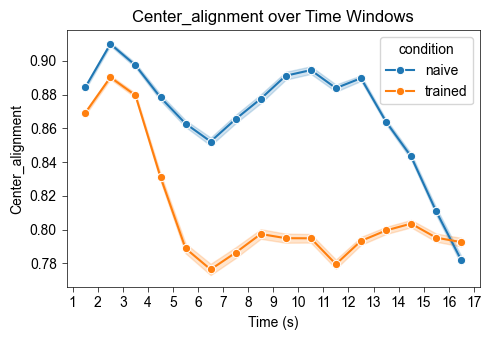

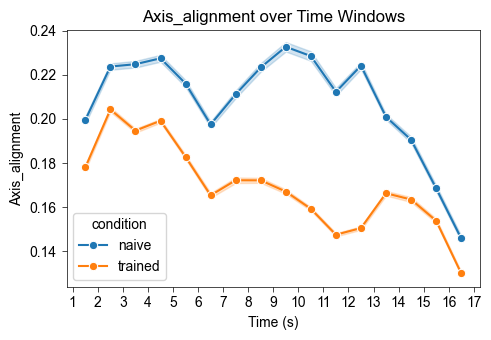

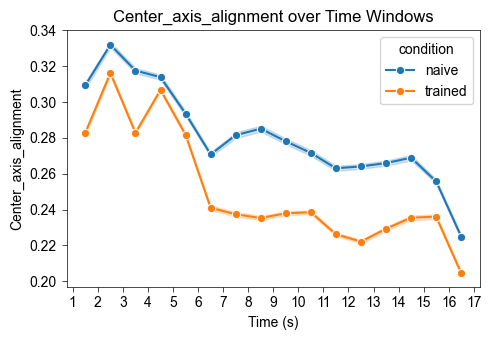

In [23]:

for measure in ['capacity', 'radius', 'dimension', 'center_alignment', 'axis_alignment', 'center_axis_alignment']:
    fig, ax = plot_measure_over_time_windows(capdf, measure=measure, window_col='middle_time', hue_col='condition')
    # Set x lim
    #ax.set_xlim((0,11))
    # Set x axis interval
    from matplotlib.ticker import MultipleLocator
    ax.xaxis.set_major_locator(MultipleLocator(1))
    # Save figure
    fig_name = f'{measure}_timecourse.pdf'
    fig_path = pjoin(paper_fig_dir, fig_name)
    #fig.savefig(fig_path)
    

In [24]:
capdf

condition  \
fish_id                            odor1 odor2 shuffle seed              
Extracted_Data_mock1_Fish1         His   Trp   False   8888      naive   
                                   Ala   His   False   8887      naive   
                                         Trp   False   8891      naive   
                                   Ser   Trp   False   8890      naive   
                                   His   Ser   False   8892      naive   
...                                                                ...   
Extracted_Data_ExpA10_Setup3_Fish1 Ala   Trp   False   18980   trained   
                                   His   Trp   False   18983   trained   
                                         Ser   False   18982   trained   
                                   Ala   Ser   False   18979   trained   
                                   Ser   Trp   False   18984   trained   

                                                              window_0  \
fish_id                            odor1 odor2 shuffle seed              
Extracted_Data_mock1_Fish1         His   Trp   False   8888         25   
                                   Ala   His   False   8887         25   
                                         Trp   False   8891         25   
                                   Ser   Trp   False   8890         25   
                                   His   Ser   False   8892         25   
...                                                                ...   
Extracted_Data_ExpA10_Setup3_Fish1 Ala   Trp   False   18980       122   
                                   His   Trp   False   18983       122   
                                         Ser   False   18982       122   
                                   Ala   Ser   False   18979       122   
                                   Ser   Trp   False   18984       122   

                                                              window_1  \
fish_id                            odor1 odor2 shuffle seed              
Extracted_Data_mock1_Fish1         His   Trp   False   8888         48   
                                   Ala   His   False   8887         48   
                                         Trp   False   8891         48   
                                   Ser   Trp   False   8890         48   
                                   His   Ser   False   8892         48   
...                                                                ...   
Extracted_Data_ExpA10_Setup3_Fish1 Ala   Trp   False   18980       146   
                                   His   Trp   False   18983       146   
                                         Ser   False   18982       146   
                                   Ala   Ser   False   18979       146   
                                   Ser   Trp   False   18984       146   

                                                              capacity  \
fish_id                            odor1 odor2 shuffle seed              
Extracted_Data_mock1_Fish1         His   Trp   False   8888   0.064754   
                                   Ala   His   False   8887   0.093279   
                                         Trp   False   8891   0.075982   
                                   Ser   Trp   False   8890   0.071848   
                                   His   Ser   False   8892   0.061800   
...                                                                ...   
Extracted_Data_ExpA10_Setup3_Fish1 Ala   Trp   False   18980  0.117372   
                                   His   Trp   False   18983  0.115774   
                                         Ser   False   18982  0.122783   
                                   Ala   Ser   False   18979  0.085452   
                                   Ser   Trp   False   18984  0.128292   

                                                              dimension  \
fish_id                            odor1 odor2 shuffle seed               
Extracted_Data_mock1_Fish1         His   Trp   False   8888

In [25]:
# window in frames to window in seconds: (window / 7.5 - 3.3).round()
capdf['start_time'] = (capdf['window_0'] / dsconfig.frame_rate - 3.3)
capdf['end_time'] = (capdf['window_1'] / dsconfig.frame_rate - 3.3)

capdf_to_save = capdf[['condition', 'window_0', 'window_1', 'start_time', 'end_time', 'capacity', 'radius', 'dimension', 'center_alignment', 'axis_alignment']]

# Save result data to CSV
figure_data_dir = os.path.join('../../publish_dataset/Hu_Temiz_et_al_dataset', 'figure_data')
os.makedirs(figure_data_dir, exist_ok=True)
save_dir = os.path.join(figure_data_dir, 'extended_figure09')
os.makedirs(save_dir, exist_ok=True)
capdf_to_save.to_csv(os.path.join(save_dir, f'extended_figure09k_adult_capacity_and_geometric_measures_timecourse.csv'))